#Simulación Monte Carlo de las Propieades Magnéticas y Efecto Magnetocalórico en un Antiferromagneto Tipo-A: Estudio del Modelo de Ising 2D
*Fundamentos en Magnetismo*

Sofía Moscoso Ortíz

---



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numba import njit, prange
# ==================

#Parte A: Implementacion y Calibracion
Funciones Base. Implementacion del modelo, condiciones de frontera y algoritmo de metropolis.

In [9]:
@njit(cache=True, fastmath=True)
def energia_local(grid, i, j, N, J1, J2, periodic):
  ip1 = i + 1
  im1 = i - 1
  jp1 = j + 1
  jm1 = j - 1

  if periodic: #condiciones de frontera periodicas
    if ip1 == N: ip1 = 0            #ejemplo
    if im1 == -1: im1 = N - 1       # 0,0 | 0,1 | 0,2
    if jp1 == N: jp1 = 0            # 1,0 | 1,1 | 1,2
    if jm1 == -1: jm1 = N - 1       # 2,0 | 2,1 | 2,2

    sumFM  = grid[im1, j] + grid[ip1, j] + grid[i, jm1] + grid[i, jp1]
    sumAFM = grid[im1, jm1] + grid[ip1, jm1] + grid[im1, jp1] + grid[ip1, jp1]

  else:  # condiciones de fronteras libres
    has_up    = i > 0
    has_down  = i < N - 1
    has_left  = j > 0
    has_right = j < N - 1

    sumFM = 0.0                                 #ejemplo
    if has_up:    sumFM += grid[im1, j]         # 0,0 | 0,1 | 0,2
    if has_down:  sumFM += grid[ip1, j]         # 1,0 | 1,1 | 1,2
    if has_left:  sumFM += grid[i, jm1]         # 2,0 | 2,1 | 2,2
    if has_right: sumFM += grid[i, jp1]

    sumAFM = 0.0
    if has_up and has_left:    sumAFM += grid[im1, jm1]
    if has_up and has_right:   sumAFM += grid[im1, jp1]
    if has_down and has_left:  sumAFM += grid[ip1, jm1]
    if has_down and has_right: sumAFM += grid[ip1, jp1]

  return -grid[i, j] * (J1 * sumFM + J2 * sumAFM)


@njit(cache=True, fastmath=True)
def Energy_total(grid, periodic):
  N = grid.shape[0]
  J1, J2 = 1.0, -0.6
  E = 0.0
  for a in range(N):
    for b in range(N):
      E += energia_local(grid, a, b, N, J1, J2, periodic)
  return E / 2.0


@njit(cache=True, fastmath=True)
def magnetizacion(grid):

  L = grid.shape[0]

  i, j = np.indices(grid.shape)

  patron = (-1)**j
  patronh = (-1)**i

  Ms_v = abs(np.sum(grid * patron)) / (L*L)
  Ms_h = abs(np.sum(grid * patronh)) / (L*L)

  return max(Ms_v, Ms_h)



# @njit(cache=True, fastmath=True)
# def magnetizacion(grid):
#   N = grid.shape[0]

#   suma_col_A = 0.0
#   suma_col_B = 0.0
#   suma_row_A = 0.0
#   suma_row_B = 0.0

#   for i in range(N):
#     for j in range(N):

#       s = grid[i, j]
#       if j % 2 == 0:          # máscara vertical (columnas)
#         suma_col_A += s
#       else:
#         suma_col_B += s

#       if i % 2 == 0:          # máscara horizontal (filas)
#         suma_row_A += s
#       else:
#         suma_row_B += s

#   Ms_col = abs(suma_col_A - suma_col_B) / (N * N)
#   Ms_row = abs(suma_row_A - suma_row_B) / (N * N)

#   return max(Ms_col, Ms_row)


@njit(cache=True, fastmath=True)
def MCS(L, N, J1, J2, T, kB, periodic):    #Implementacion del modelo

  grid = np.empty((L, L), dtype=np.int8)

  for i in range(L):
    for j in range(L):
        grid[i, j] = 1 if np.random.random() < 0.5 else -1

  E = np.empty(N)
  M = np.empty(N)

  for y in range(N):
    for k in range(L * L):
      a = np.random.randint(0, L)
      b = np.random.randint(0, L)

      E_initial = energia_local(grid, a, b, L, J1, J2, periodic)  #Algoritmo de metropolis
      delta_E = -2.0 * E_initial

      if delta_E < 0 or np.random.random() < np.exp(-delta_E / (kB * T)):
        grid[a, b] *= -1

    E[y] = Energy_total(grid, periodic)
    M[y] = magnetizacion(grid)

  return E, M

##Pruebas

In [ ]:
E_ , M_ = MCS(L=16 , N=100000 , J1=1 , J2=-0.6 , T=0.5 , kB=1 , periodic =True)

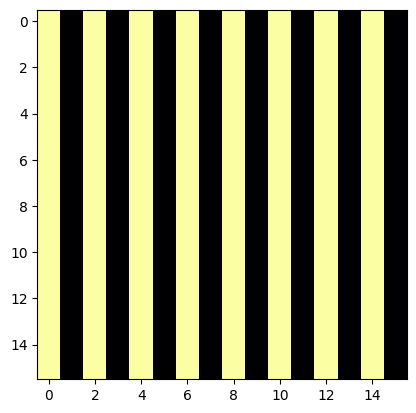

In [ ]:
plt.imshow(grid, cmap='inferno', vmin=-1, vmax=1, interpolation='nearest')

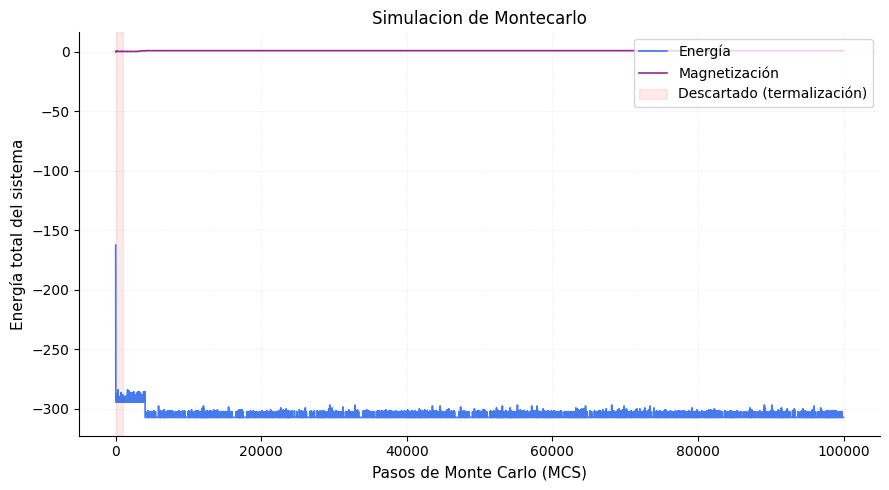

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(E_, color='#2563eb', linewidth=1.2, alpha=0.85, label='Energía')
ax.plot(M_, color='purple', linewidth=1.2, alpha=0.85, label='Magnetización')
ax.axvspan(0, 1000, color='#f87171', alpha=0.15, label=f'Descartado (termalización)')
#ax.axvline(x=1000, color='#dc2626', linestyle='--', linewidth=1.5, label=f'$t_{{eq}}$ = {1000}')    # Línea vertical en t_eq

ax.set_xlabel("Pasos de Monte Carlo (MCS)", fontsize=11)
ax.set_ylabel("Energía total del sistema", fontsize=11)
ax.set_title("Simulacion de Montecarlo")
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.grid(alpha=0.25, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Nota: En temperaturas menores a 0.4K dificilmente se da la termalizacion o simplemente no se da.

##Condiciones de Frontera Libres vs Condiciones de Frontera Periodicas
Visualizacion de la energía

In [ ]:
E_libre, M_libre = MCS(L=16, N=100000, J1=1, J2=-0.6, T=0.5 , kB=1, periodic=False)
E_p, M_p = MCS(L=16, N=100000, J1=1, J2=-0.6, T=0.5 , kB=1, periodic=True)

/tmp/ipykernel_4255/242864361.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


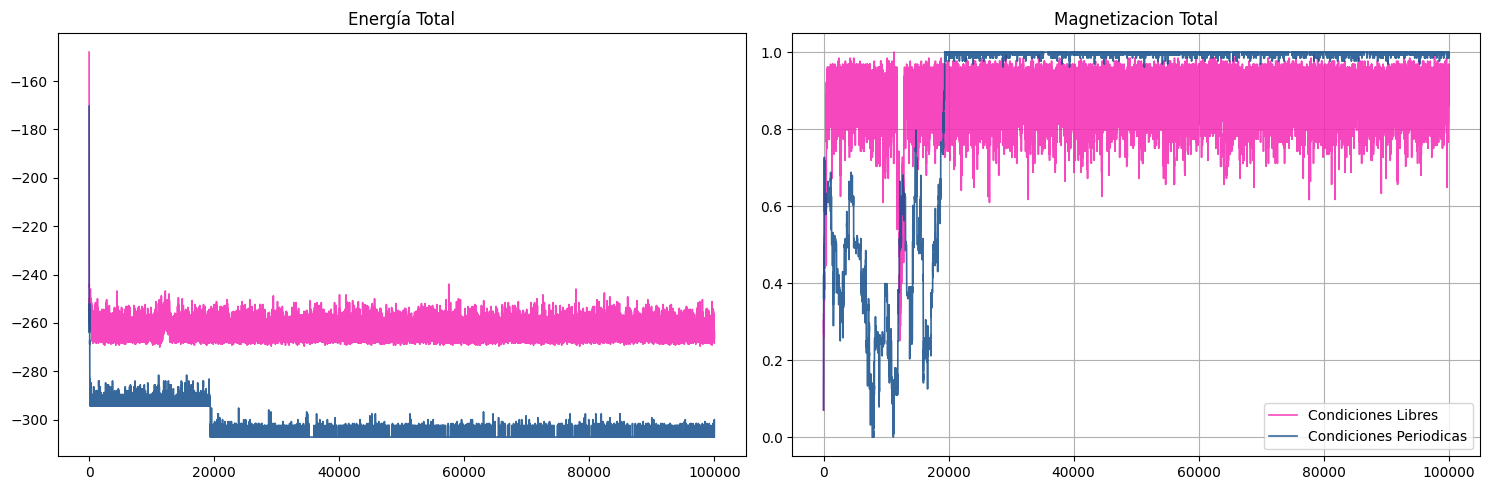

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(E_libre, color='#F527B4', linewidth=1.2, alpha=0.85, label='Condiciones Libres')
axs[0].plot(E_p, color='#134E8A', linewidth=1.2, alpha=0.85, label='Condiciones Periodicas')
axs[0].set_title('Energía Total')
#axs[0].axvline(x=t_li[30], color='red', linestyle='--', linewidth=1.5, label=f'$tlibres_{{eq}}$ = {t_li[900]}')
#axs[0].axvline(x=t_p[30], color='blue', linestyle='--', linewidth=1.5, label=f'$tperiodicas_{{eq}}$ = {t_p[0]}')


axs[1].plot(M_libre, color='#F527B4', linewidth=1.2, alpha=0.85, label='Condiciones Libres')
axs[1].plot(M_p, color='#134E8A', linewidth=1.2, alpha=0.85, label='Condiciones Periodicas')
axs[1].set_title('Magnetizacion Total')
#axs[1].axvline(x=0, color='#dc2626', linestyle='--', linewidth=1.5, label=f'$t_{{eq}}$ = {0}')

plt.grid()
plt.tight_layout()
plt.grid()
plt.legend()
plt.show()

Nota: En el sistema con condiciones de frontera libres la energía es mayor. Ademas, el calculo de los observables es más inestable. La curva de magnetizacion tarda mucho tiempo en estabilizarse o simplemente no se estabiliza.

##Simulacion
Para cada tamaño de red y para cada condicion de frontera, simular el
sistema en un rango de temperaturas (ej. 0,1 ≤ T ≤ 3,0 en unidades de J1/kB, con
J2/J1 = −0,6, que es el caso base del artıculo). Calcular el promedio de Ms, E, χs, Cv,
U.

In [10]:
@njit(cache=True, fastmath=True, parallel=True)
def barrido_temperaturas(L, N, T_array, J1, J2, kB, periodic):
    n_T = len(T_array)
    E_temperatures = np.empty((n_T, N))
    M_temperatures = np.empty((n_T, N))

    for t in prange(n_T):
        E, M = MCS(L, N, J1, J2, T_array[t], kB, periodic)
        E_temperatures[t, :] = E
        M_temperatures[t, :] = M

    return E_temperatures, M_temperatures

In [11]:
T =np.linspace(1.5,0.6, 40)

In [12]:
E16_temperatures, M16_temperatures = barrido_temperaturas(
    L=16, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=True
)

E24_temperatures, M24_temperatures = barrido_temperaturas(
    L=24, N=100000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=True
)


In [29]:

E16_temperatures_free, M16_temperatures_free = barrido_temperaturas(
    L=16, N=500000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=False
)

E24_temperatures_free, M24_temperatures_free = barrido_temperaturas(
    L=24, N=500000, T_array=T, J1=1.0, J2=-0.6, kB=1.0, periodic=False
)

###Visualizar Datos

In [14]:
def visualizacion(lista, titulo='MCS'):

    titulos = ['0.85', '0.83', ' 0.8', '0.78','0.76', ' 0.73', '0.71', '0.69', "0.66" , "0.64" , "0.62" , "0.6" ]

    fig, axs = plt.subplots(3, 4, figsize=(18, 8))

    fig.suptitle(titulo, fontsize=18, fontweight='bold')

    for ax, E, nombre in zip(axs.flat, lista, titulos):

        ax.plot(E, linewidth=1.2)

        ax.set_title(nombre)
        ax.set_xlabel('Pasos MC')
        ax.set_ylabel('Observable')

        # Mismo eje X para las 8
        #x.set_xlim(0, 50000)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    plt.show()

In [13]:
T

array([1.5       , 1.47692308, 1.45384615, 1.43076923, 1.40769231,
       1.38461538, 1.36153846, 1.33846154, 1.31538462, 1.29230769,
       1.26923077, 1.24615385, 1.22307692, 1.2       , 1.17692308,
       1.15384615, 1.13076923, 1.10769231, 1.08461538, 1.06153846,
       1.03846154, 1.01538462, 0.99230769, 0.96923077, 0.94615385,
       0.92307692, 0.9       , 0.87692308, 0.85384615, 0.83076923,
       0.80769231, 0.78461538, 0.76153846, 0.73846154, 0.71538462,
       0.69230769, 0.66923077, 0.64615385, 0.62307692, 0.6       ])

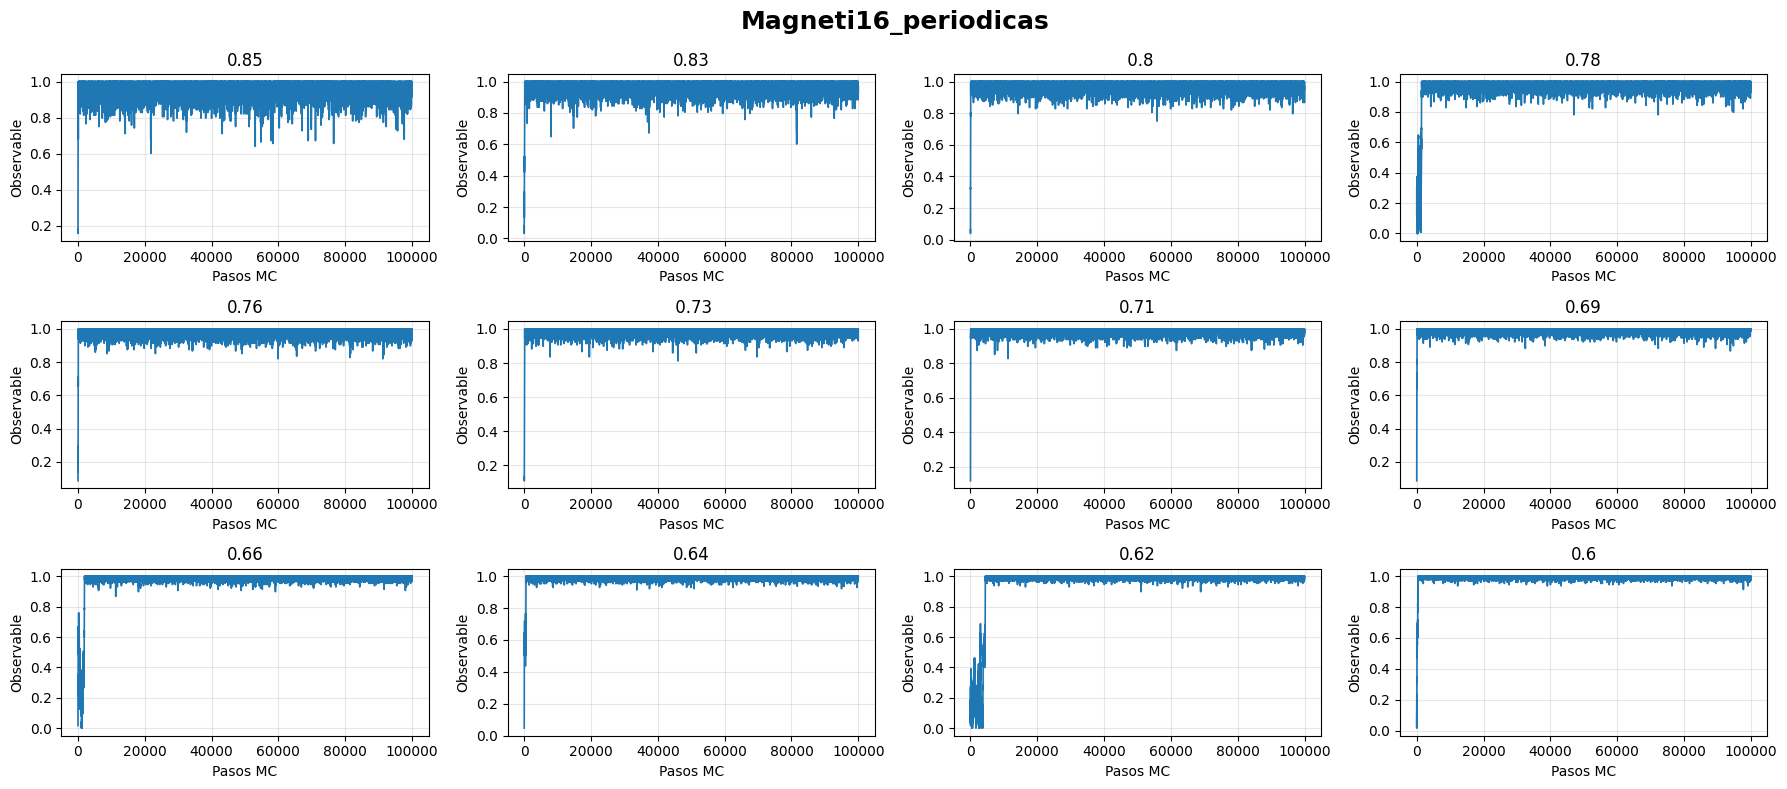

In [15]:
visualizacion(M16_temperatures[28:], "Magneti16_periodicas")

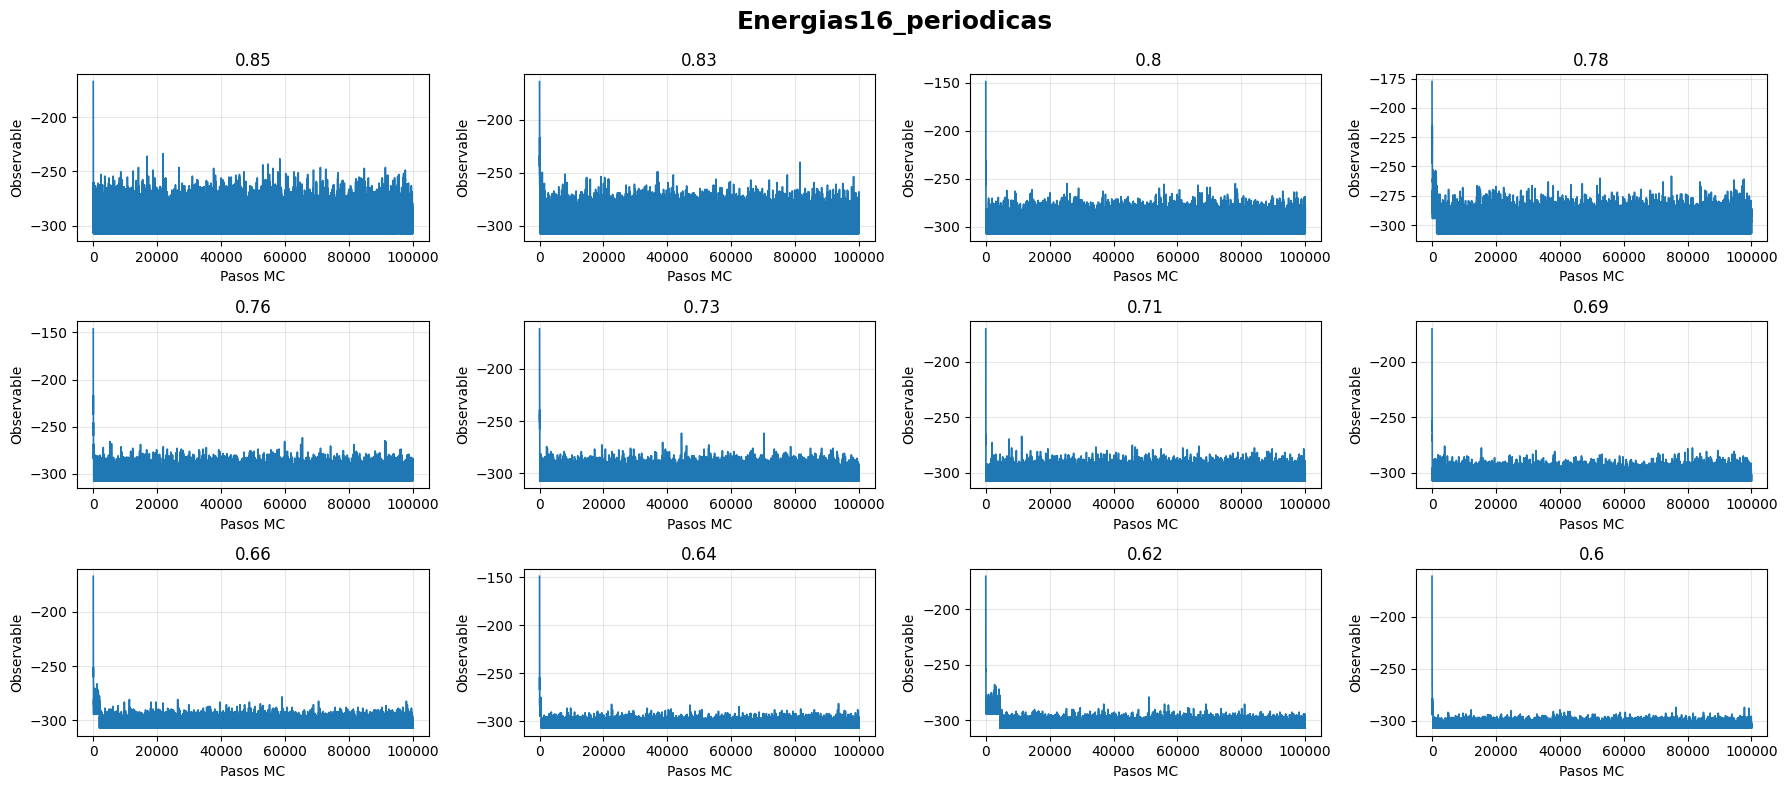

In [17]:
visualizacion(E16_temperatures[28:], "Energias16_periodicas")

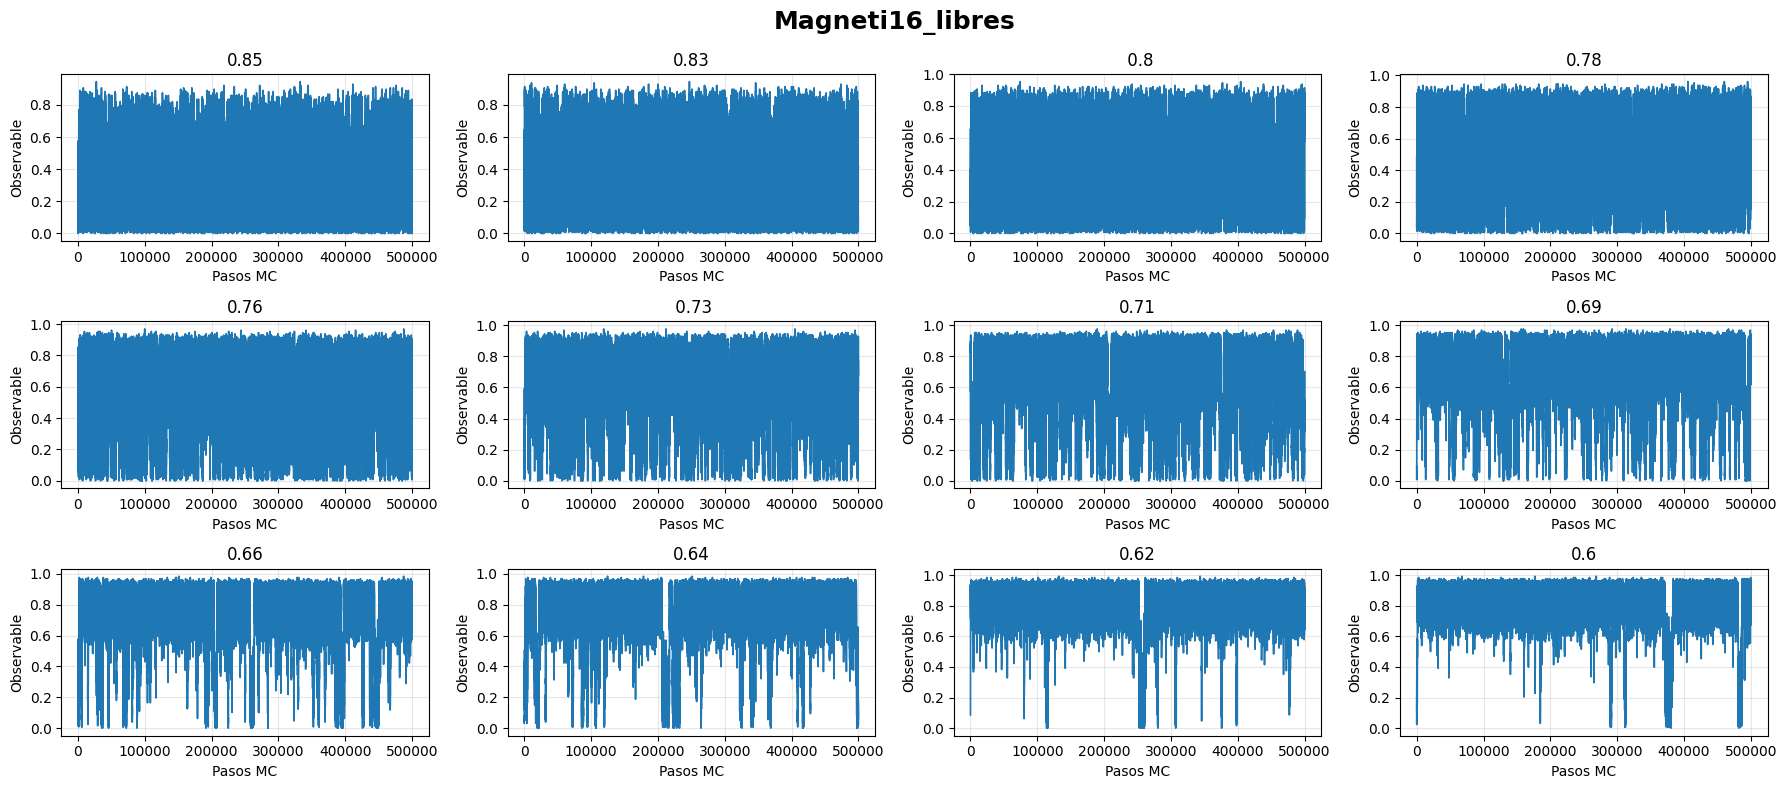

In [31]:
visualizacion(M16_temperatures_free[28:], "Magneti16_libres")

In [ ]:
T

array([1.5       , 1.47435897, 1.44871795, 1.42307692, 1.3974359 ,
       1.37179487, 1.34615385, 1.32051282, 1.29487179, 1.26923077,
       1.24358974, 1.21794872, 1.19230769, 1.16666667, 1.14102564,
       1.11538462, 1.08974359, 1.06410256, 1.03846154, 1.01282051,
       0.98717949, 0.96153846, 0.93589744, 0.91025641, 0.88461538,
       0.85897436, 0.83333333, 0.80769231, 0.78205128, 0.75641026,
       0.73076923, 0.70512821, 0.67948718, 0.65384615, 0.62820513,
       0.6025641 , 0.57692308, 0.55128205, 0.52564103, 0.5       ])

###Energia vs Temperatura

In [32]:
def Energy(energias):
  E_prom= []
  for E in energias:
    E_prom.append(np.array(E[100000:]).mean())
  return E_prom

In [20]:
Eprom_16 = Energy(E16_temperatures)
Eprom_24 = Energy(E24_temperatures)

Mprom_16 = Energy(M16_temperatures)
Mprom_24 = Energy(M24_temperatures)

In [33]:
Eprom_16_f = Energy(E16_temperatures_free)
Eprom_24_f = Energy(E24_temperatures_free)

Mprom_16_f = Energy(M16_temperatures_free)
Mprom_24_f = Energy(M24_temperatures_free)

Fijate en la asimetría: a T=0.5-0.8, el sistema ordena perfectamente y rápido (Ms→1 en pocos miles de pasos). Pero a T=0.4 hacia abajo, en vez de ordenar mejor (que es lo que la física predice — más frío debería significar más orden), el sistema queda atrapado en valores bajos, erráticos, o en mesetas que no son el estado de equilibrio real.

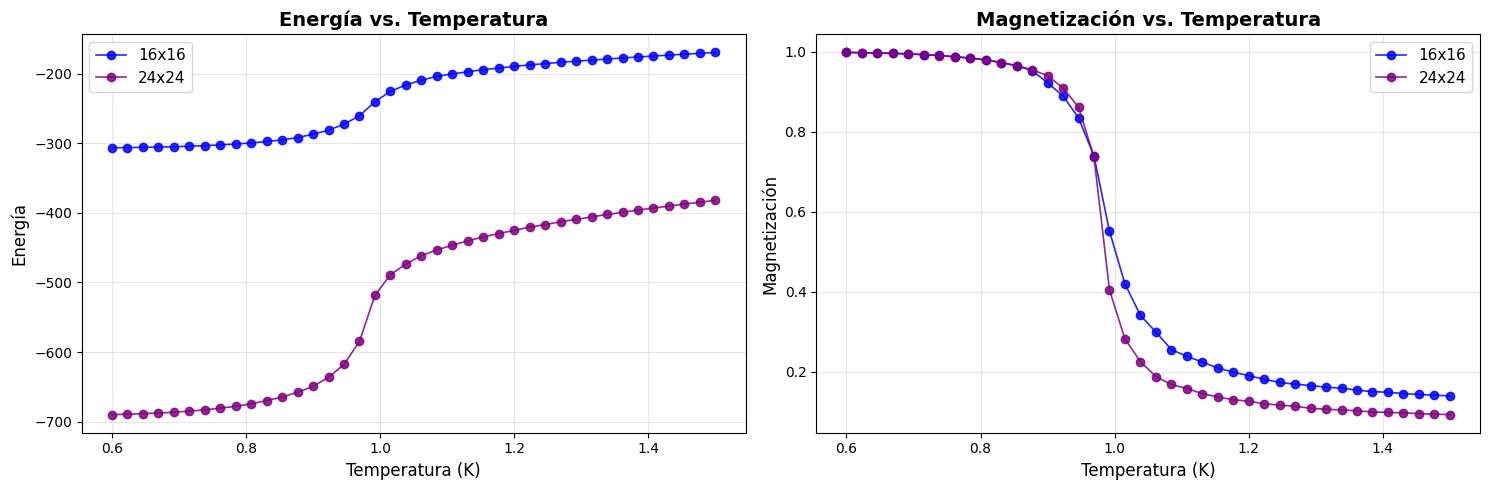

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(T, Eprom_16, "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, Eprom_24,  "-o",color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Energía vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, Mprom_16, "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, Mprom_24, "-o", color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].set_title('MagnetizacionVSTemperatura')
axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

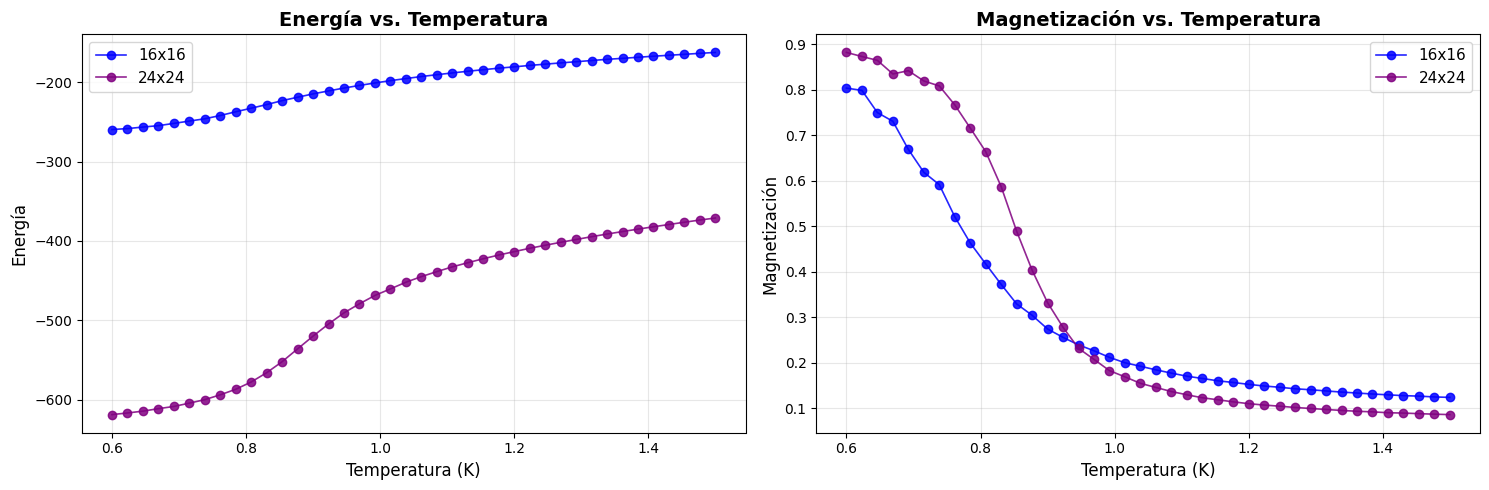

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(T, Eprom_16_f, "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, Eprom_24_f,  "-o",color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Energía vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, Mprom_16_f, "-o", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, Mprom_24_f, "-o", color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].set_title('MagnetizacionVSTemperatura')
axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()

###Gran promedio
Energía y magnetización configuracionales

In [51]:
@njit(cache=True, fastmath=True, parallel=False)
def GranMean(L, N, Temp, n_configs=10, t_rx=20000):
    J1, J2 = 1.0, -0.6
    kB = 1.0

    E_config = np.empty(n_configs)
    M_config = np.empty(n_configs)

    for c in prange(n_configs):
        E_, M_ = MCS(L, N, J1, J2, Temp, kB, periodic=True)
        E_config[c] = E_[t_rx:].mean()
        M_config[c] = M_[t_rx:].mean()

    return E_config, M_config

In [52]:
@njit(cache=True, fastmath=True, parallel=True)
def barrido_GranMean(L, N, T_array, n_configs=10, t_rx=20000):
    n_T = len(T_array)
    E_config_all = np.empty((n_T, n_configs))
    M_config_all = np.empty((n_T, n_configs))

    for t in prange(n_T):
        E_c, M_c = GranMean(L, N, T_array[t], n_configs, t_rx)  # GranMean debe ser secuencial (sin parallel=True)
        E_config_all[t, :] = E_c
        M_config_all[t, :] = M_c

    return E_config_all, M_config_all

In [53]:
E16_config, M16_config = barrido_GranMean(L=16, N=100000, T_array=T)
E24_config, M24_config = barrido_GranMean(L=24, N=100000, T_array=T) #12minutos

In [ ]:
E16_config_free, M16_config_free = barrido_GranMean(L=16, N=100000, T_array=T)
E24_config_free, M24_config_free = barrido_GranMean(L=24, N=100000, T_array=T)

In [ ]:
#GUARDAR DATOS
# --------------------------------------------------------------------
def construir_formato_largo(T, E_temperaturas, M_temperaturas, L):
    filas = []
    for t, E_array, M_array in zip(T, E_temperaturas, M_temperaturas):
        E_array = np.asarray(E_array)
        M_array = np.asarray(M_array)
        n_pasos = len(E_array)
        for paso in range(n_pasos):
            filas.append({
                "L": L,
                "T": t,
                "paso": paso,
                "E": E_array[paso],
                "M": M_array[paso],
            })
    return pd.DataFrame(filas)


df_L16_largo = construir_formato_largo(T, E16_config, M16_config, L=16)
df_L24_largo = construir_formato_largo(T, E24_config, M24_config, L=24)

df_L16_largo_free = construir_formato_largo(T, E16_config_free, M16_config_free, L=16)
df_L24_largo_free = construir_formato_largo(T,E24_config_free, M24_config_free, L=24)

with pd.ExcelWriter("resultados_MCS_libres.xlsx", engine="openpyxl") as writer:
    df_L16_largo.to_excel(writer, sheet_name="L16", index=False)
    df_L24_largo.to_excel(writer, sheet_name="L24", index=False)

    df_L16_largo_free.to_excel(writer, sheet_name="L16f", index=False)
    df_L24_largo_free.to_excel(writer, sheet_name="L24f", index=False)

print("Guardado: resultados_MCS_libres.xlsx")


In [54]:
E16_config = np.array(E16_config)
M16_config = np.array(M16_config)

E24_config = np.array(E24_config)
M24_config = np.array(M24_config)

In [ ]:
E16_config_free = np.array(E16_config_free)
M16_config_free = np.array(M16_config_free)

E24_config_free = np.array(E24_config_free)
M24_config_free = np.array(M24_config_free)

In [55]:
E16_std  = E16_config.std(axis=1, ddof=1)      # ddof=1: desviación estándar muestral (no poblacional)
E16_sem  = E16_std / np.sqrt(E16_config.shape[1])  # dividir por sqrt(n_configs)
M16_std  = M16_config.std(axis=1, ddof=1)
M16_sem  = M16_std / np.sqrt(M16_config.shape[1])



E24_std  = E24_config.std(axis=1, ddof=1)
E24_sem  = E24_std / np.sqrt(E24_config.shape[1])
M24_std  = M24_config.std(axis=1, ddof=1)
M24_sem  = M24_std / np.sqrt(M24_config.shape[1])

In [ ]:


E16_std_free  = E16_config.std(axis=1, ddof=1)
E16_sem_free  = E16_std / np.sqrt(E16_config.shape[1])
M16_std_free  = M16_config.std(axis=1, ddof=1)
M16_sem_free  = M16_std / np.sqrt(M16_config.shape[1])

E24_std_free  = E24_config.std(axis=1, ddof=1)
E24_sem_free  = E24_std / np.sqrt(E24_config.shape[1])
M24_std_free  = M24_config.std(axis=1, ddof=1)
M24_sem_free  = M24_std / np.sqrt(M24_config.shape[1])

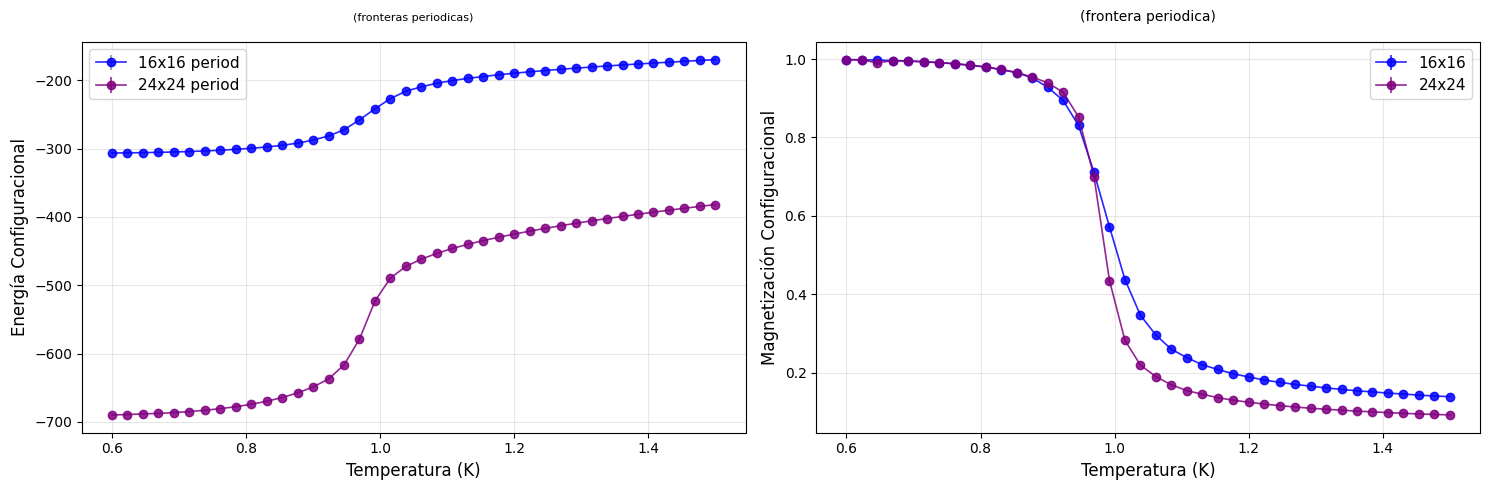

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))


axs[0].errorbar(T, E16_config.mean(axis=1), yerr=E16_sem, fmt ="o-" , color='blue', ecolor='gray', linewidth=1.2, alpha=0.85, label='16x16 period')
axs[0].errorbar(T, E24_config.mean(axis=1), yerr=E24_sem, fmt ="o-", color='purple', linewidth=1.2, alpha=0.85, label='24x24 period')
#axs[0].plot(T, E16_config_free.mean(axis=1),  "-o", color='red', linewidth=1.2, alpha=0.85, label='16x16 free')
#axs[0].plot(T, E24_config_free.mean(axis=1), "-o", color='orange', linewidth=1.2, alpha=0.85, label='24x24 free')
axs[0].set_title('Energía vs. Temperatura ', fontsize=14, fontweight='bold')
axs[0].set_title("(fronteras periodicas)", fontsize=8, loc="center", pad=15)
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Energía Configuracional', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].errorbar(T, M16_config.mean(axis=1), yerr=M16_sem, fmt ="o-" , color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].errorbar(T, M24_config.mean(axis=1), yerr=M24_sem, fmt ="o-" ,  color='purple', linewidth=1.2, alpha=0.85, label='24x24')
#axs[1].plot(T, M16_config_free.mean(axis=1), "-o", color='red', linewidth=1.2, alpha=0.85, label='16x16 free')
#axs[1].plot(T, M24_config_free.mean(axis=1),  "-o", color='orange', linewidth=1.2, alpha=0.85, label='24x24 free')
axs[1].set_title('Magnetización vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_title("(frontera periodica)", fontsize=10, loc="center", pad=15)
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Magnetización Configuracional', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


plt.tight_layout()
plt.show()


Calcular χs, Cv y U a partir de las muestras


In [39]:
def observables(E, Ms, L, T, kB):  #arrays configuracionales
    E = np.array(E[100000:])
    Ms = np.array(Ms[100000:])
    N = L * L

    # Promedios simples
    E_mean = E.mean()
    Ms_mean = Ms.mean()

    # Promedios de potencias (necesarios para varianza y Binder)
    E2_mean = (E**2).mean()
    Ms2_mean = (Ms**2).mean()
    Ms4_mean = (Ms**4).mean()

    # Calor específico
    Cv = (E2_mean - E_mean**2) / (N * kB * T**2)

    # Susceptibilidad de subred
    chi_s = (N / (kB * T)) * (Ms2_mean - Ms_mean**2)

    # Cumulante de Binder
    U = 1 - Ms4_mean / (3 * Ms2_mean**2)

    return Cv , chi_s , U

In [37]:
#para L = 16          #periodicas
Cv16, chi_s16, U16 = [] , [], []

for i in range(len(E16_temperatures)):
  Cv, chi_s, U = observables(E16_temperatures[i], M16_temperatures[i] , 16 , T[i] , 1)

  Cv16.append(Cv)
  chi_s16.append(chi_s)
  U16.append(U)

#para L = 24
Cv24, chi_s24, U24 = [] , [], []
for i in range(len(E24_temperatures)):
  Cv, chi_s, U = observables(E24_temperatures[i], M24_temperatures[i] , 24 , T[i] , 1)

  Cv24.append(Cv)
  chi_s24.append(chi_s)
  U24.append(U)

In [40]:
#para L = 16          #libres
Cv16_f, chi_s16_f, U16_f = [] , [], []
for i in range(len(E16_temperatures_free)):
  Cv, chi_s, U = observables(E16_temperatures_free[i], M16_temperatures_free[i] , 16 , T[i] , 1)

  Cv16_f.append(Cv)
  chi_s16_f.append(chi_s)
  U16_f.append(U)

#para L = 24
Cv24_f, chi_s24_f, U24_f = [] , [], []
for i in range(len(E24_temperatures_free)):
  Cv, chi_s, U = observables(E24_temperatures_free[i], M24_temperatures_free[i] , 24 , T[i] , 1)

  Cv24_f.append(Cv)
  chi_s24_f.append(chi_s)
  U24_f.append(U)

#Parte B: Analisis de Resultados

##Trancisiones de fase y condiciones de Frontera
Grafique Ms(T) y χs(T) para ambos tama˜nos de red y ambas condiciones de
frontera.


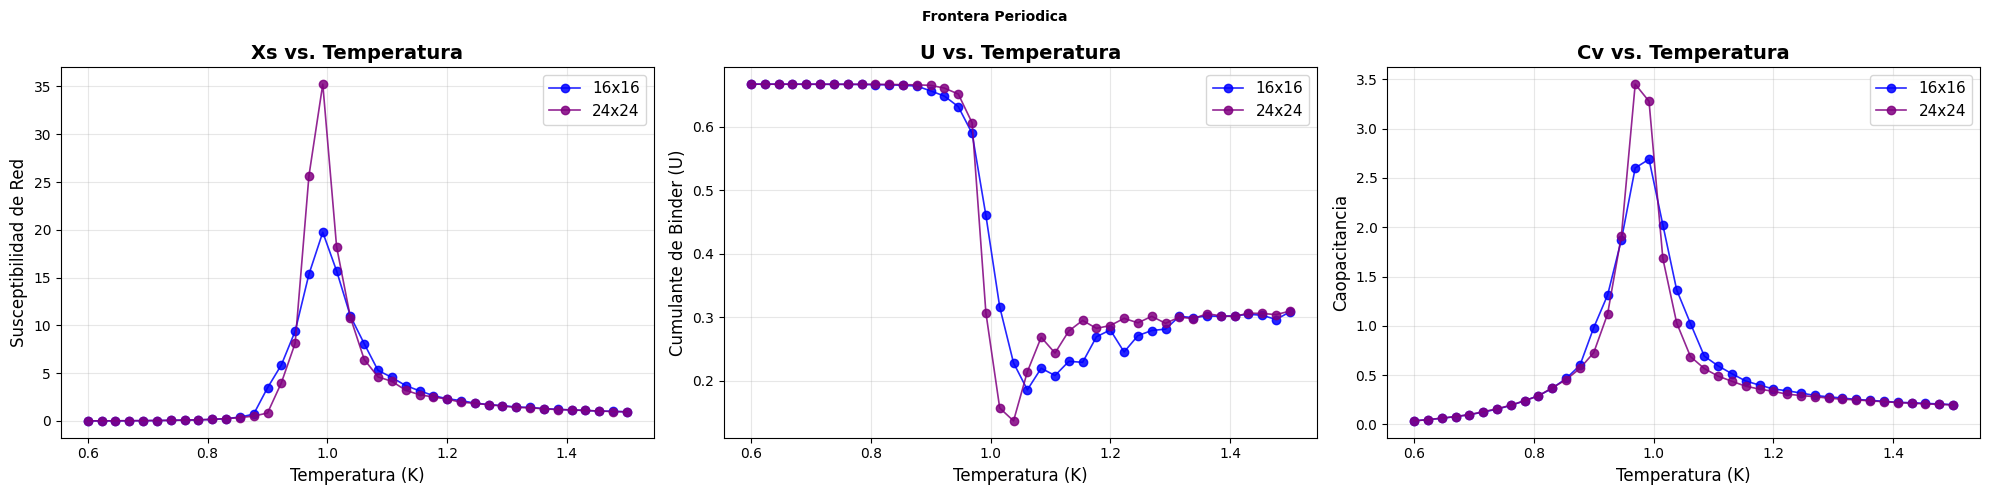

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Frontera Periodica', fontsize=10, fontweight='bold')


axs[0].plot(T, chi_s16, "o-", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, chi_s24, "o-",color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Xs vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Susceptibilidad de Red', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, U16, "o-",color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, U24,"o-", color='purple', linewidth=1.2, alpha=0.85, label="24x24")
axs[1].set_title('U vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder (U)', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


axs[2].plot(T, Cv16, "o-",color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[2].plot(T,Cv24 , "o-",color='purple', linewidth=1.2, alpha=0.85, label="24x24")
axs[2].set_title('Cv vs. Temperatura', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Temperatura (K)', fontsize=12)
axs[2].set_ylabel('Caopacitancia', fontsize=12)
axs[2].grid(True, alpha=0.3)
axs[2].legend(fontsize=11)
axs[2].tick_params(labelsize=10)


plt.tight_layout()
plt.show()


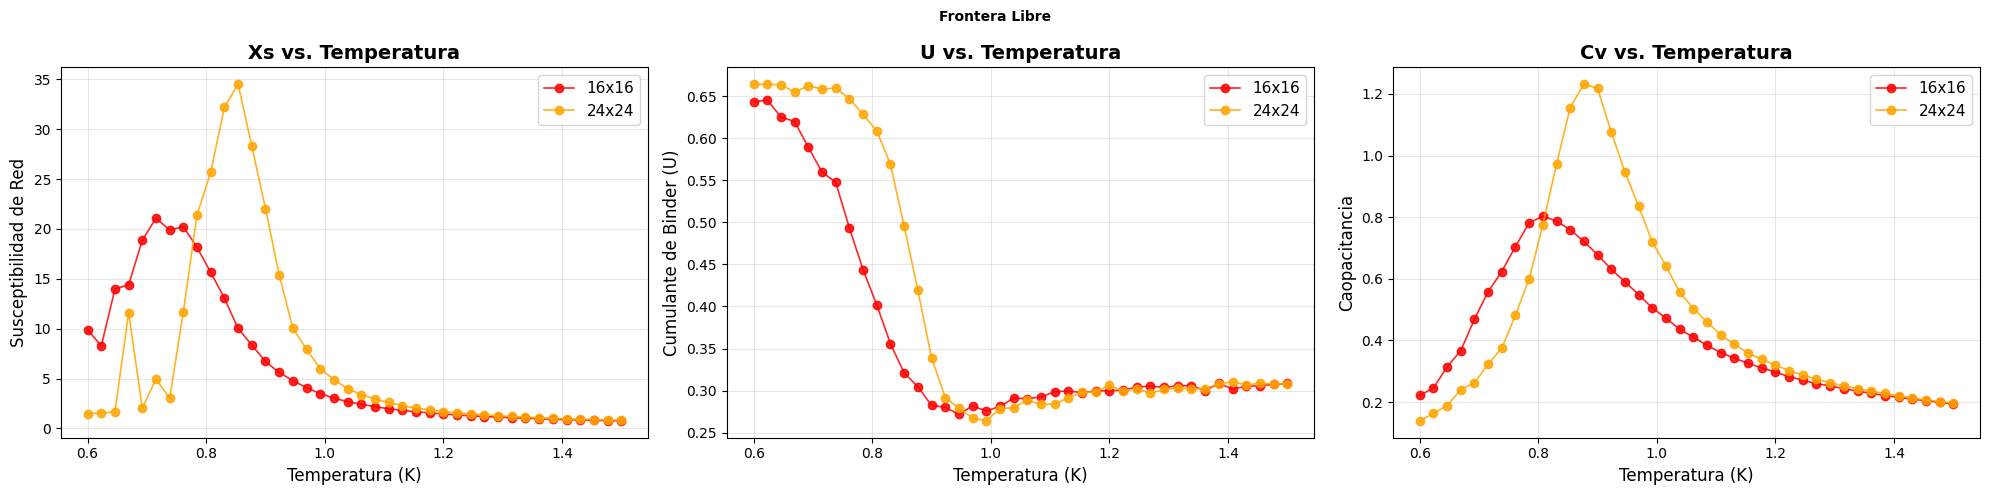

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Frontera Libre', fontsize=10, fontweight='bold')

axs[0].plot(T, chi_s16_f, "o-", color='red', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, chi_s24_f, "o-", color='orange', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Xs vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Susceptibilidad de Red', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, U16_f,"o-", color='red', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, U24_f,"o-", color='orange', linewidth=1.2, alpha=0.85, label="24x24")

axs[1].set_title('U vs. Temperatura',  fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder (U)', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


axs[2].plot(T, Cv16_f,"o-", color='red', linewidth=1.2, alpha=0.85, label='16x16')
axs[2].plot(T,Cv24_f ,"o-", color='orange', linewidth=1.2, alpha=0.85, label="24x24")

axs[2].set_title('Cv vs. Temperatura', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Temperatura (K)', fontsize=12)
axs[2].set_ylabel('Caopacitancia', fontsize=12)
axs[2].grid(True, alpha=0.3)
axs[2].legend(fontsize=11)
axs[2].tick_params(labelsize=10)


plt.tight_layout()
plt.show()


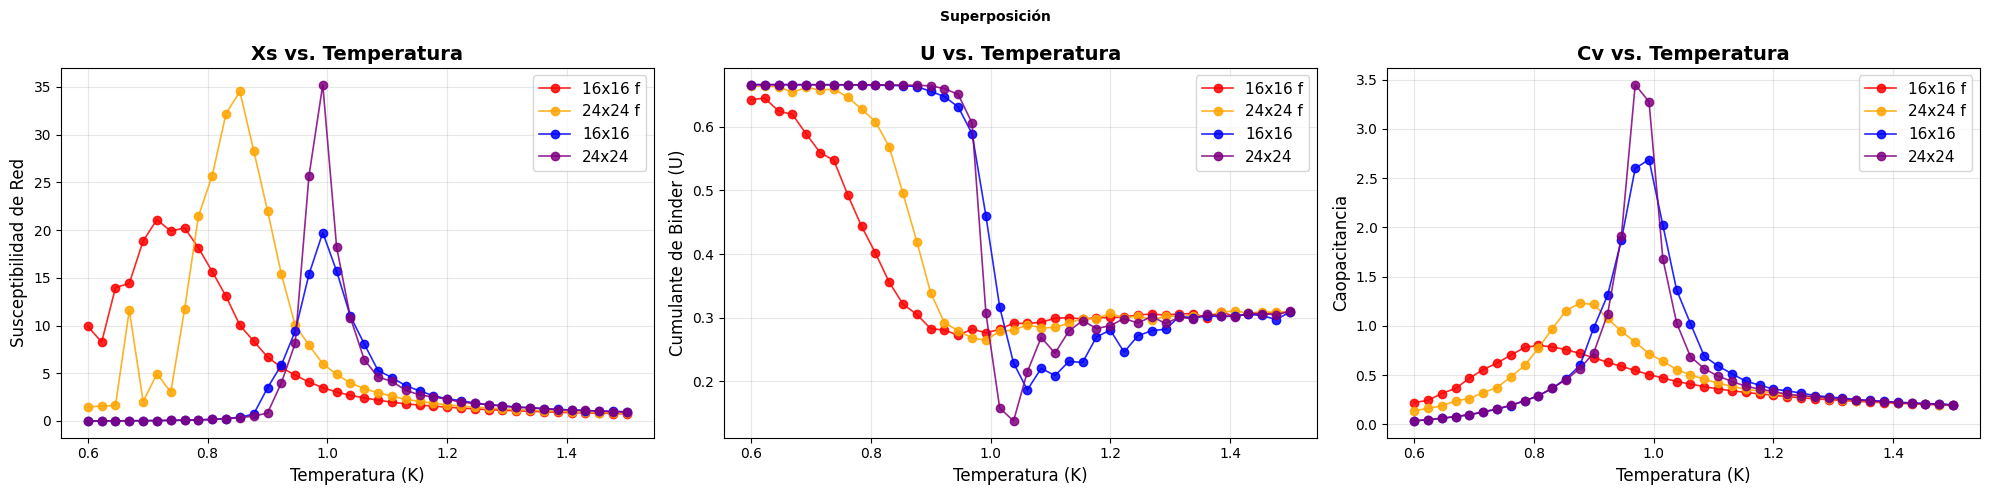

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Superposición', fontsize=10, fontweight='bold')

axs[0].plot(T, chi_s16_f,"o-", color='red', linewidth=1.2, alpha=0.85, label='16x16 f')
axs[0].plot(T, chi_s24_f,"o-", color='orange', linewidth=1.2, alpha=0.85, label='24x24 f')
axs[0].plot(T, chi_s16, "o-",color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, chi_s24, "o-",color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Xs vs. Temperatura', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Susceptibilidad de Red', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, U16_f, "o-", color='red', linewidth=1.2, alpha=0.85, label='16x16 f')
axs[1].plot(T, U24_f, "o-", color='orange', linewidth=1.2, alpha=0.85, label="24x24 f")

axs[1].plot(T, U16, "o-", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, U24, "o-", color='purple', linewidth=1.2, alpha=0.85, label="24x24")

axs[1].set_title('U vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder (U)', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)


axs[2].plot(T, Cv16_f, "o-", color='red', linewidth=1.2, alpha=0.85, label='16x16 f')
axs[2].plot(T,Cv24_f , "o-", color='orange', linewidth=1.2, alpha=0.85, label="24x24 f")
axs[2].plot(T, Cv16, "o-", color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[2].plot(T,Cv24 , "o-",color='purple', linewidth=1.2, alpha=0.85, label="24x24")
axs[2].set_title('Cv vs. Temperatura', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Temperatura (K)', fontsize=12)
axs[2].set_ylabel('Caopacitancia', fontsize=12)
axs[2].grid(True, alpha=0.3)
axs[2].legend(fontsize=11)
axs[2].tick_params(labelsize=10)


plt.tight_layout()
plt.show()


Pregunta 1: ¿Como afectan las condiciones de frontera a la forma de Ms(T) y
χs(T) cerca de la transicion? ¿Que condicion de frontera se asemeja mas al lımite
termodinamico y por que?

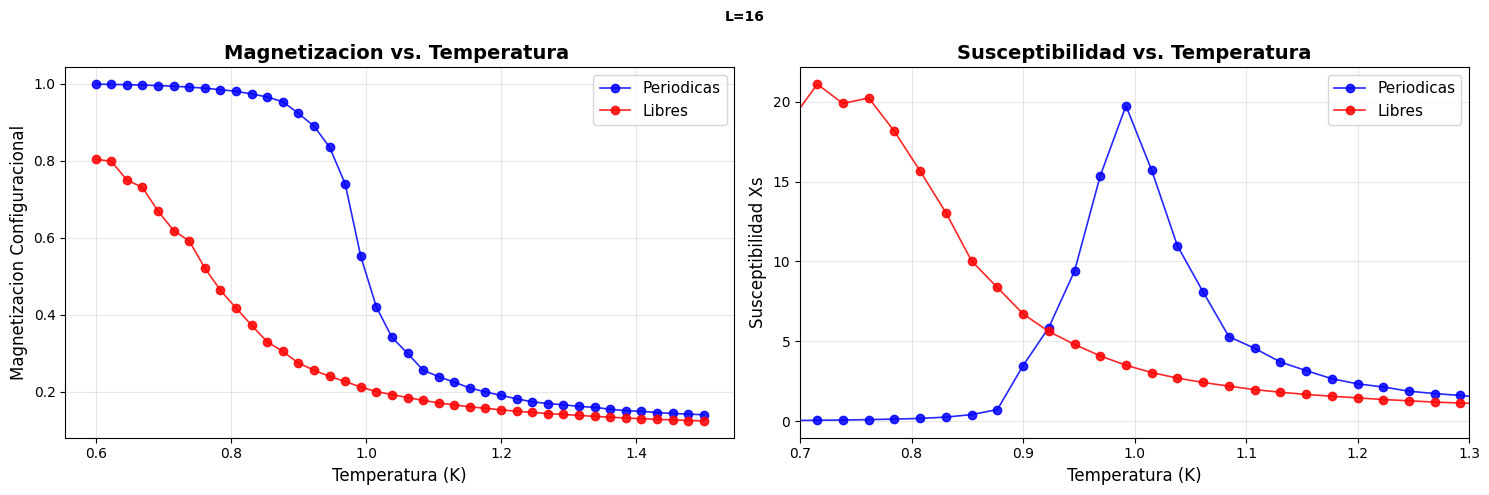

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('L=16', fontsize=10, fontweight='bold')

axs[0].plot(T, Mprom_16, "-o", color='blue', linewidth=1.2, alpha=0.85, label='Periodicas')
axs[0].plot(T, Mprom_16_f,"-o" ,color='red', linewidth=1.2, alpha=0.85, label='Libres')
axs[0].set_title('Magnetizacion vs. Temperatura ', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Magnetizacion Configuracional', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, chi_s16, "-o", color='blue', linewidth=1.2, alpha=0.85, label='Periodicas')
axs[1].plot(T, chi_s16_f,"-o", color='red', linewidth=1.2, alpha=0.85, label='Libres')
axs[1].set_title('Susceptibilidad vs. Temperatura', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Susceptibilidad Xs', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)
axs[1].set_xlim(0.7, 1.3)

plt.tight_layout()
plt.show()


Usando el Cumulante de Binder U(T), determine la temperatura de
Neel TN para cada condicion de frontera. ¿Que metodo (T del pico de χs o cruce de
U) da una estimacion mas estable? Justifique su respuesta.


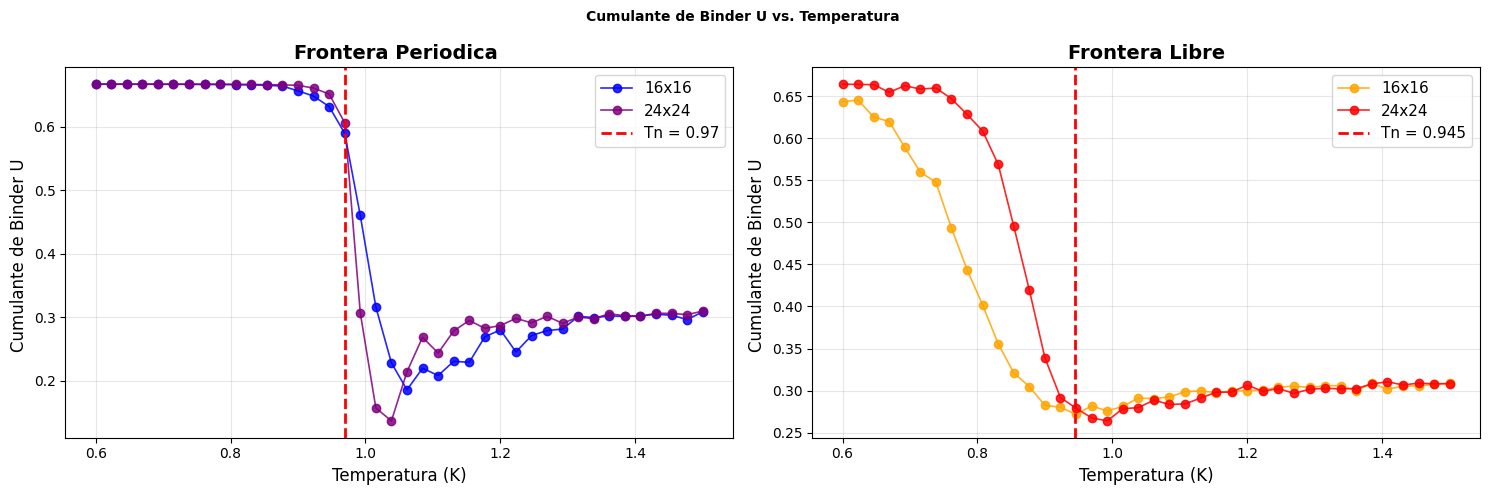

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Cumulante de Binder U vs. Temperatura ', fontsize=10, fontweight='bold')

axs[0].plot(T, U16,"o-",  color='blue', linewidth=1.2, alpha=0.85, label='16x16')
axs[0].plot(T, U24,"o-",  color='purple', linewidth=1.2, alpha=0.85, label='24x24')
axs[0].set_title('Frontera Periodica ', fontsize=14, fontweight='bold')
axs[0].axvline(x=0.97, color='red', linestyle='--', linewidth=2, label='Tn = 0.97')
axs[0].set_xlabel('Temperatura (K)', fontsize=12)
axs[0].set_ylabel('Cumulante de Binder U ', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=11)
axs[0].tick_params(labelsize=10)

axs[1].plot(T, U16_f, "o-", color='orange', linewidth=1.2, alpha=0.85, label='16x16')
axs[1].plot(T, U24_f, "o-", color='red', linewidth=1.2, alpha=0.85, label='24x24')
axs[1].axvline(x=0.945, color='red', linestyle='--', linewidth=2, label='Tn = 0.945')
axs[1].set_title('Frontera Libre', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Temperatura (K)', fontsize=12)
axs[1].set_ylabel('Cumulante de Binder U ', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=11)
axs[1].tick_params(labelsize=10)

plt.tight_layout()
plt.show()


##Efecto Magnetocalorico
Para el sistema con condiciones de frontera peri´odicas y L = 24:



In [57]:
@njit(cache=True, fastmath=True)
def magnetizacion_total(grid):      #MAGNETIZACION UNIFORME
    # Magnetización total del sistema, NO de subred
    N = grid.shape[0]
    suma = 0.0
    for i in range(N):
        for j in range(N):
            suma += grid[i, j]
    return abs(suma) / (N * N)


@njit(cache=True, fastmath=True)
def MCS_h(L, N, J1, J2, T, kB, periodic, h):  #MSC con h
    grid = np.empty((L, L), dtype=np.int8)
    for i in range(L):
        for j in range(L):
            grid[i, j] = 1 if np.random.random() < 0.5 else -1

    E = np.empty(N)
    M = np.empty(N)

    for y in range(N):
        for k in range(L * L):
            a = np.random.randint(0, L)
            b = np.random.randint(0, L)

            E_int = energia_local(grid, a, b, L, J1, J2, periodic)
            # delta_E sin campo: -2*E_int
            # término de campo: al voltear s -> -s, -h*s pasa a +h*s => contribución 2*h*s
            delta_E = -2.0 * E_int + 2.0 * h * grid[a, b]

            if delta_E < 0 or np.random.random() < np.exp(-delta_E / (kB * T)):
                grid[a, b] *= -1

        # energía total incluyendo término Zeeman (sin doble conteo, es a un solo cuerpo)
        campo_total = 0.0
        for i in range(L):
            for j in range(L):
                campo_total += grid[i, j]

        E[y] = Energy_total(grid, periodic) - h * campo_total
        M[y] = magnetizacion_total(grid)

    return E, M

In [58]:
@njit(cache=True, fastmath=True)
def GranMean_h(L, N, Temp, h, n_configs=10, t_rx=20000):
    J1, J2 = 1.0, -0.6
    kB = 1.0

    E_config = np.empty(n_configs)
    M_config = np.empty(n_configs)

    for c in range(n_configs):
        E_, M_ = MCS_h(L, N, J1, J2, Temp, kB, True, h)  # periodic=True
        E_config[c] = E_[t_rx:].mean()
        M_config[c] = M_[t_rx:].mean()

    return E_config, M_config


@njit(cache=True, fastmath=True, parallel=True)
def barrido_GranMean_h(L, N, T_array, h, n_configs=10, t_rx=20000):
    n_T = len(T_array)
    E_config_all = np.empty((n_T, n_configs))
    M_config_all = np.empty((n_T, n_configs))

    for t in prange(n_T):
        E_c, M_c = GranMean_h(L, N, T_array[t], h, n_configs, t_rx)
        E_config_all[t, :] = E_c
        M_config_all[t, :] = M_c

    return E_config_all, M_config_all

Realice simulaciones con y sin campo magnetico externo (h). Por simplicidad,
calcule ∆SM usando el metodo de integracion numerica de la relacion de
Maxwell. Grafique ∆SM(T) para las dos condiciones de campo.

In [59]:
T2 =np.linspace(0.6,1.5, 40)

In [60]:
t_rx = 20000  #42min

# Sin campo
E_h0_all, M_h0_all = barrido_GranMean_h(24, 100000, T, h=0.0, t_rx=t_rx)
M_h0 = M_h0_all.mean(axis=1)   # promedio sobre las 10 configs

# Con campo
E_h1_all, M_h1_all = barrido_GranMean_h(24, 100000, T, h=0.5, t_rx=t_rx)
M_h1 = M_h1_all.mean(axis=1)

In [61]:
def delta_SM(T, M):
    """
    Aplica ec. (7): ΔS_M(T) ≈ [M(T+ΔT) - M(T-ΔT)] / (2ΔT)
    usando diferencias centradas en el interior y forward/backward en los bordes.
    """
    dT = T[1] - T[0]  # asume malla uniforme (np.linspace la garantiza)
    dS = np.gradient(M, dT)  # np.gradient ya hace centrada adentro, forward/backward en bordes
    return dS


In [66]:
M_h0_ = M_h0[::-1]
M_h1_ = M_h1[::-1]
T_ = T[::-1]

In [67]:
dS_h0 = delta_SM(T_, M_h0_)
dS_h1 = delta_SM(T_, M_h1_)

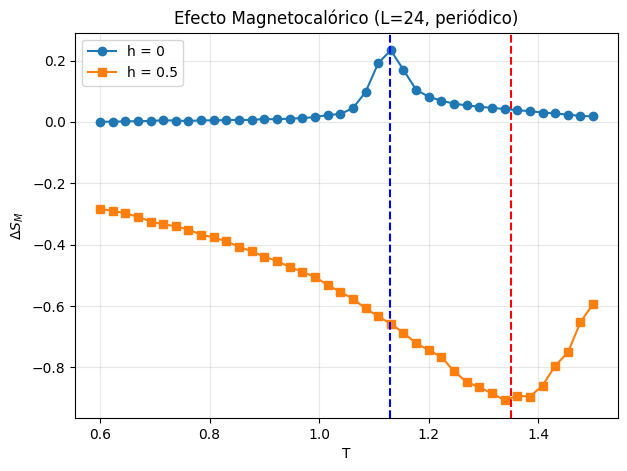

In [71]:
plt.figure(figsize=(7,5))
plt.plot(T, dS_h0, 'o-', label='h = 0')
plt.plot(T, dS_h1, 's-', label='h = 0.5')
plt.axvline(x=1.13, color='blue', linestyle='--')
plt.axvline(x=1.35, color='red', linestyle='--')
plt.xlabel('T')
plt.ylabel(r'$\Delta S_M$')
plt.title('Efecto Magnetocalórico (L=24, periódico)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Pregunta 3: ¿Por que el efecto magnetocalorico (maximo en |∆SM|) ocurre cerca
de TN ? Relacione esto con la fısica de la transicion de fase.

Calcule el RCP para el campo h = 0,5 (usando el FWHM del pico de
|∆SM|). ¿Qu´e implicaci´on tiene este valor para una posible aplicaci´on como refrigerante magn´etico? Compare cualitativamente con la magnitud del RCP reportada
en el art´ıculo para el modelo de Heisenberg.

##Analisis Crıtico y Comparacion con el Modelo Original


Pregunta 5 (Escalado de tama˜no finito): ¿C´omo esperar´ıa que Ms(T) y χs(T)
cambien a medida que L → ∞? Discuta si los valores de TN encontrados para
L = 24 son una buena aproximaci´on al valor del l´ımite termodin´amico.

Pregunta 6 (Comparaci´on de Modelos): El art´ıculo original usa un modelo
de Heisenberg 3D y encuentra exponentes cr´ıticos de la clase de universalidad de
Ising 3D. En nuestro modelo de Ising 2D, ¿esperar´ıa que los exponentes cr´ıticos
(ej. β) fueran los mismos? Justifique su respuesta bas´andose en la teor´ıa de grupos
de renormalizaci´on y las clases de universalidad. ¿Por qu´e los autores del art´ıculo
pudieron usar un modelo 3D pero obtener exponentes de Ising?
